In [1]:
# ==============================================================================
# Deep Learning Based Predictive Maintenance for Induction Motors
# Using Hybrid CNN-LSTM Architecture
# Dataset: Fault Induction Motor Dataset (Uysal Serkan)
# ==============================================================================

# 1. INSTALLING REQUIRED PACKAGES

import sys
!{sys.executable} -m pip install kagglehub numpy pandas scikit-learn tensorflow matplotlib seaborn scipy imbalanced-learn tqdm plotly

In [2]:
# 2. IMPORTING ALL NECESSARY LIBRARIES
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_recall_fscore_support,
                           roc_curve, auc, roc_auc_score)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, LSTM, 
                                    Dense, Dropout, Flatten, BatchNormalization,
                                    concatenate, GlobalAveragePooling1D, 
                                    Bidirectional, Attention, Multiply)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, 
                                       ModelCheckpoint, TensorBoard, 
                                       CSVLogger)
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.regularizers import l1_l2
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.stats import kurtosis, skew, entropy
import warnings
warnings.filterwarnings('ignore')
import joblib
import json
from datetime import datetime
import kagglehub
import zipfile
import glob

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# 3. DOWNLOADING AND LOADING DATASET
def download_and_load_dataset():
    """
    Download and load the Fault Induction Motor Dataset from Kaggle
    """
    print("="*70)
    print("DOWNLOADING FAULT INDUCTION MOTOR DATASET")
    print("="*70)
    
    try:
        # Download dataset using kagglehub
        path = kagglehub.dataset_download("uysalserkan/fault-induction-motor-dataset")
        print(f"Dataset downloaded to: {path}")
        
        # List files in the dataset
        dataset_files = os.listdir(path)
        print(f"Files in dataset: {dataset_files}")
        
        # The dataset contains multiple CSV files for different conditions
        # Based on the dataset description, files are named by condition
        
        # Define file mapping based on typical structure of this dataset
        file_mapping = {
            'normal': ['normal.csv', 'Normal.csv', 'NORMAL.csv', 'Normal_Condition.csv'],
            'broken_rotor_bar': ['broken_rotor_bar.csv', 'BRB.csv', 'Rotor_Fault.csv'],
            'stator_fault': ['stator_fault.csv', 'stator.csv', 'Stator_Fault.csv'],
            'bearing_fault': ['bearing_fault.csv', 'bearing.csv', 'Bearing_Fault.csv'],
            'voltage_unbalance': ['voltage_unbalance.csv', 'unbalance.csv'],
            'overload': ['overload.csv', 'Overload.csv']
        }
        
        all_data = []
        all_labels = []
        
        # Try to load each condition
        conditions = []
        for condition, possible_filenames in file_mapping.items():
            found = False
            for filename in possible_filenames:
                file_path = os.path.join(path, filename)
                if os.path.exists(file_path):
                    print(f"Loading {condition} data from {filename}")
                    df = pd.read_csv(file_path)
                    
                    # Add label column
                    df['condition'] = condition
                    df['label'] = condition
                    
                    all_data.append(df)
                    conditions.append(condition)
                    found = True
                    print(f"  Samples: {len(df)}, Columns: {df.columns.tolist()}")
                    break
            
            if not found:
                # Try pattern matching
                pattern = os.path.join(path, f"*{condition}*.csv")
                matching_files = glob.glob(pattern, recursive=True)
                if matching_files:
                    print(f"Loading {condition} data from {matching_files[0]}")
                    df = pd.read_csv(matching_files[0])
                    df['condition'] = condition
                    df['label'] = condition
                    all_data.append(df)
                    conditions.append(condition)
        
        if not all_data:
            # If no files found with above patterns, look for any CSV files
            csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
            print(f"Found CSV files: {csv_files}")
            
            # Create synthetic data if no CSV files found
            if not csv_files:
                print("No CSV files found. Creating synthetic data for demonstration...")
                return create_synthetic_motor_data()
            
            # Load all CSV files
            for csv_file in csv_files:
                try:
                    df = pd.read_csv(csv_file)
                    # Try to infer condition from filename
                    filename = os.path.basename(csv_file)
                    condition = filename.split('.')[0].lower()
                    
                    df['condition'] = condition
                    df['label'] = condition
                    all_data.append(df)
                    conditions.append(condition)
                    print(f"Loaded {filename}: {len(df)} samples")
                except Exception as e:
                    print(f"Error loading {csv_file}: {e}")
        
        # Combine all data
        combined_df = pd.concat(all_data, ignore_index=True)
        
        print("\n" + "="*70)
        print("DATASET SUMMARY")
        print("="*70)
        print(f"Total samples: {len(combined_df)}")
        print(f"Conditions found: {combined_df['condition'].unique()}")
        print(f"Columns: {combined_df.columns.tolist()}")
        print(f"\nClass distribution:")
        print(combined_df['condition'].value_counts())
        
        return combined_df
    
    except Exception as e:
        print(f"Error downloading/loading dataset: {e}")
        print("Creating synthetic data for demonstration...")
        return create_synthetic_motor_data()

def create_synthetic_motor_data():
    """
    Create synthetic induction motor fault data if real dataset is unavailable
    """
    print("Creating synthetic induction motor fault data...")
    
    n_samples = 10000
    n_features = 8
    time_steps = 1024  # For time-series data
    
    # Define conditions based on the actual dataset
    conditions = {
        'normal': 0,
        'broken_rotor_bar': 1,
        'stator_fault': 2,
        'bearing_fault': 3,
        'voltage_unbalance': 4,
        'overload': 5
    }
    
    # Create synthetic data for each condition
    all_data = []
    
    for condition, label in conditions.items():
        n_class_samples = n_samples // len(conditions)
        
        for _ in range(n_class_samples):
            # Create time-series data
            t = np.linspace(0, 1, time_steps)
            
            # Base 50Hz signal (motor frequency)
            base_signal = np.sin(2 * np.pi * 50 * t)
            
            # Add harmonics based on condition
            if condition == 'normal':
                signal_data = base_signal + 0.1 * np.random.randn(time_steps)
                
            elif condition == 'broken_rotor_bar':
                # Characteristic frequencies for broken rotor bar
                fault_freq = 0.1  # Side bands around fundamental
                fault_signal = 0.3 * np.sin(2 * np.pi * (50 - fault_freq) * t)
                signal_data = base_signal + fault_signal + 0.15 * np.random.randn(time_steps)
                
            elif condition == 'stator_fault':
                # Higher frequency components for stator faults
                fault_signal = 0.2 * np.sin(2 * np.pi * 100 * t)
                signal_data = base_signal + fault_signal + 0.2 * np.random.randn(time_steps)
                
            elif condition == 'bearing_fault':
                # Impulse-like signals for bearing faults
                impulses = np.zeros(time_steps)
                n_impulses = np.random.randint(5, 15)
                impulse_positions = np.random.choice(time_steps, n_impulses, replace=False)
                impulses[impulse_positions] = np.random.randn(n_impulses) * 2
                # Add exponential decay
                for i in range(1, time_steps):
                    impulses[i] += 0.9 * impulses[i-1]
                signal_data = base_signal + 0.4 * impulses + 0.25 * np.random.randn(time_steps)
                
            elif condition == 'voltage_unbalance':
                # Asymmetric waveforms
                unbalance_factor = 0.2
                unbalance_signal = unbalance_factor * np.sin(2 * np.pi * 50 * t + np.pi/3)
                signal_data = base_signal + unbalance_signal + 0.12 * np.random.randn(time_steps)
                
            elif condition == 'overload':
                # Amplitude modulation
                load_factor = 1 + 0.3 * np.sin(2 * np.pi * 0.5 * t)
                signal_data = load_factor * base_signal + 0.18 * np.random.randn(time_steps)
            
            # Create feature vector
            features = {}
            for i in range(n_features):
                # Different sensors with correlated signals
                phase_shift = i * np.pi / 4
                sensor_signal = signal_data * np.cos(phase_shift) + 0.1 * np.random.randn(time_steps)
                
                # Calculate statistical features
                features[f'current_phase_{i}'] = np.mean(sensor_signal)
                features[f'vibration_{i}'] = np.std(sensor_signal)
                features[f'temp_{i}'] = np.max(sensor_signal) - np.min(sensor_signal)
                features[f'fft_{i}'] = np.abs(fft(sensor_signal)[10])  # 10th frequency component
            
            # Add time-series data
            features['time_series'] = signal_data[:128]  # First 128 points
            
            features['condition'] = condition
            features['label'] = label
            
            all_data.append(features)
    
    df = pd.DataFrame(all_data)
    print(f"Synthetic dataset created: {len(df)} samples")
    print(f"Conditions: {df['condition'].unique()}")
    
    return df

In [4]:
# 4. ADVANCED FEATURE ENGINEERING
def extract_time_domain_features(signal_data):
    """
    Extract time-domain statistical features
    """
    features = {}
    
    # Basic statistical features
    features['mean'] = np.mean(signal_data)
    features['std'] = np.std(signal_data)
    features['rms'] = np.sqrt(np.mean(signal_data**2))
    features['peak'] = np.max(np.abs(signal_data))
    features['peak_to_peak'] = np.ptp(signal_data)
    features['skewness'] = skew(signal_data)
    features['kurtosis'] = kurtosis(signal_data)
    
    # Shape factors
    features['crest_factor'] = features['peak'] / features['rms'] if features['rms'] != 0 else 0
    features['shape_factor'] = features['rms'] / np.mean(np.abs(signal_data)) if np.mean(np.abs(signal_data)) != 0 else 0
    features['impulse_factor'] = features['peak'] / np.mean(np.abs(signal_data)) if np.mean(np.abs(signal_data)) != 0 else 0
    
    # Additional features
    features['median'] = np.median(signal_data)
    features['mad'] = np.mean(np.abs(signal_data - features['mean']))
    features['energy'] = np.sum(signal_data**2)
    
    return features

def extract_frequency_domain_features(signal_data, sampling_rate=1000):
    """
    Extract frequency-domain features using FFT
    """
    features = {}
    
    # Compute FFT
    n = len(signal_data)
    fft_values = fft(signal_data)
    fft_magnitude = np.abs(fft_values[:n//2])
    frequencies = fftfreq(n, 1/sampling_rate)[:n//2]
    
    # Frequency domain features
    features['dominant_freq'] = frequencies[np.argmax(fft_magnitude)]
    features['max_amplitude'] = np.max(fft_magnitude)
    features['mean_freq'] = np.mean(fft_magnitude)
    features['median_freq'] = np.median(fft_magnitude)
    features['bandwidth'] = np.max(frequencies) - np.min(frequencies)
    
    # Spectral moments
    features['spectral_centroid'] = np.sum(frequencies * fft_magnitude) / np.sum(fft_magnitude) if np.sum(fft_magnitude) != 0 else 0
    features['spectral_spread'] = np.sqrt(np.sum(((frequencies - features['spectral_centroid'])**2) * fft_magnitude) / np.sum(fft_magnitude)) if np.sum(fft_magnitude) != 0 else 0
    features['spectral_skewness'] = np.sum(((frequencies - features['spectral_centroid'])**3) * fft_magnitude) / (features['spectral_spread']**3 * np.sum(fft_magnitude)) if features['spectral_spread'] != 0 and np.sum(fft_magnitude) != 0 else 0
    features['spectral_kurtosis'] = np.sum(((frequencies - features['spectral_centroid'])**4) * fft_magnitude) / (features['spectral_spread']**4 * np.sum(fft_magnitude)) if features['spectral_spread'] != 0 and np.sum(fft_magnitude) != 0 else 0
    
    # Energy in different frequency bands (typical for motor faults)
    freq_bands = {
        'low_freq': (0, 50),      # Fundamental
        'medium_freq': (50, 200),  # Harmonics
        'high_freq': (200, 500)    # High-frequency components
    }
    
    for band_name, (low, high) in freq_bands.items():
        mask = (frequencies >= low) & (frequencies <= high)
        if np.any(mask):
            features[f'energy_{band_name}'] = np.sum(fft_magnitude[mask]**2)
            features[f'mean_amp_{band_name}'] = np.mean(fft_magnitude[mask])
        else:
            features[f'energy_{band_name}'] = 0
            features[f'mean_amp_{band_name}'] = 0
    
    return features

def extract_wavelet_features(signal_data):
    """
    Extract wavelet transform features (simplified)
    """
    features = {}
    
    # Simple wavelet-like features using signal decomposition
    # In practice, you would use pywt library for proper wavelet transform
    try:
        # Approximate wavelet coefficients using simple filtering
        coeffs_approx = signal_data[::2]  # Approximation coefficients
        coeffs_detail = signal_data[1::2]  # Detail coefficients
        
        features['wavelet_approx_mean'] = np.mean(coeffs_approx)
        features['wavelet_approx_std'] = np.std(coeffs_approx)
        features['wavelet_detail_mean'] = np.mean(coeffs_detail)
        features['wavelet_detail_std'] = np.std(coeffs_detail)
        features['wavelet_energy_ratio'] = np.sum(coeffs_detail**2) / (np.sum(coeffs_approx**2) + 1e-10)
    except:
        # Fallback values
        for key in ['wavelet_approx_mean', 'wavelet_approx_std', 
                   'wavelet_detail_mean', 'wavelet_detail_std', 
                   'wavelet_energy_ratio']:
            features[key] = 0
    
    return features

def engineer_features(df, time_series_column=None):
    """
    Perform comprehensive feature engineering on the dataset
    """
    print("Performing feature engineering...")
    
    all_features = []
    
    for idx, row in df.iterrows():
        features = {}
        
        # Extract features from available columns
        # Look for time-series data or sensor readings
        signal_columns = []
        for col in df.columns:
            if any(keyword in col.lower() for keyword in ['current', 'voltage', 'vibration', 
                                                         'temp', 'signal', 'data', 'series']):
                if isinstance(row[col], (list, np.ndarray)) or (isinstance(row[col], str) and len(str(row[col])) > 50):
                    signal_columns.append(col)
        
        # If specific time series column is provided
        if time_series_column and time_series_column in df.columns:
            signal_data = row[time_series_column]
            if isinstance(signal_data, str):
                # Try to parse string representation of array
                try:
                    signal_data = np.fromstring(signal_data.strip('[]'), sep=',')
                except:
                    signal_data = np.array([float(x) for x in signal_data.split()])
        elif signal_columns:
            # Use the first signal column found
            signal_data = row[signal_columns[0]]
            if isinstance(signal_data, str):
                try:
                    signal_data = np.fromstring(signal_data.strip('[]'), sep=',')
                except:
                    signal_data = np.array([float(x) for x in signal_data.split()])
        else:
            # Create synthetic signal from numeric columns
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            signal_data = row[numeric_cols].values[:100]  # First 100 numeric values
        
        # Ensure signal_data is numpy array
        if not isinstance(signal_data, np.ndarray):
            signal_data = np.array(signal_data)
        
        # Extract features
        time_features = extract_time_domain_features(signal_data)
        freq_features = extract_frequency_domain_features(signal_data)
        wavelet_features = extract_wavelet_features(signal_data)
        
        # Combine all features
        features.update(time_features)
        features.update(freq_features)
        features.update(wavelet_features)
        
        # Add original features (excluding non-numeric and label columns)
        for col in df.columns:
            if col not in ['condition', 'label', time_series_column] + signal_columns:
                if pd.api.types.is_numeric_dtype(df[col]):
                    features[col] = row[col]
        
        # Add label
        features['condition'] = row['condition'] if 'condition' in row else 'unknown'
        features['label'] = row['label'] if 'label' in row else 0
        
        all_features.append(features)
    
    features_df = pd.DataFrame(all_features)
    
    print(f"Feature engineering completed. Original features: {len(df.columns)}, Engineered features: {len(features_df.columns)}")
    return features_df

In [5]:
# 5. DATA PREPROCESSING PIPELINE
def preprocess_data(df):
    """
    Comprehensive data preprocessing pipeline
    """
    print("\n" + "="*70)
    print("DATA PREPROCESSING")
    print("="*70)
    
    # Handle missing values
    print("1. Handling missing values...")
    df_clean = df.copy()
    
    # Drop columns with too many missing values
    missing_threshold = 0.5
    cols_to_drop = [col for col in df_clean.columns 
                    if df_clean[col].isnull().mean() > missing_threshold]
    if cols_to_drop:
        print(f"  Dropping columns with >{missing_threshold*100}% missing values: {cols_to_drop}")
        df_clean = df_clean.drop(columns=cols_to_drop)
    
    # Fill remaining missing values
    for col in df_clean.columns:
        if df_clean[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df_clean[col]):
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            else:
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'unknown')
    
    # Encode categorical labels
    print("2. Encoding labels...")
    if 'condition' in df_clean.columns:
        le = LabelEncoder()
        df_clean['label_encoded'] = le.fit_transform(df_clean['condition'])
        class_names = le.classes_
        n_classes = len(class_names)
        print(f"  Classes: {class_names}")
        print(f"  Class distribution:\n{df_clean['condition'].value_counts()}")
    else:
        print("  Warning: No 'condition' column found. Creating synthetic labels.")
        df_clean['condition'] = 'unknown'
        df_clean['label_encoded'] = 0
        class_names = ['unknown']
        n_classes = 1
    
    # Separate features and labels
    print("3. Separating features and labels...")
    
    # Identify feature columns (exclude label columns)
    exclude_cols = ['condition', 'label', 'label_encoded', 'time_series']
    feature_cols = [col for col in df_clean.columns if col not in exclude_cols]
    
    X = df_clean[feature_cols].values
    y = df_clean['label_encoded'].values
    
    print(f"  Feature matrix shape: {X.shape}")
    print(f"  Labels shape: {y.shape}")
    
    # Handle class imbalance
    print("4. Handling class imbalance...")
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    
    # Check if we have enough samples for SMOTE
    unique_classes, class_counts = np.unique(y, return_counts=True)
    min_samples = min(class_counts)
    
    if n_classes > 1 and min_samples > 5:  # Need at least 5 samples per class for SMOTE
        smote = SMOTE(random_state=42, k_neighbors=min(5, min_samples - 1))
        X_resampled, y_resampled = smote.fit_resample(X, y)
        print(f"  After SMOTE - X: {X_resampled.shape}, y: {y_resampled.shape}")
        X, y = X_resampled, y_resampled
    else:
        print("  Not enough samples for SMOTE. Using original distribution.")
    
    # Normalize features
    print("5. Normalizing features...")
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(X)
    
    # Save the scaler for future use
    joblib.dump(scaler, 'feature_scaler.pkl')
    
    # Split data
    print("6. Splitting data...")
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_normalized, y, test_size=0.3, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
    
    # Convert to categorical for neural network
    y_train_cat = to_categorical(y_train, num_classes=n_classes)
    y_val_cat = to_categorical(y_val, num_classes=n_classes)
    y_test_cat = to_categorical(y_test, num_classes=n_classes)
    
    print(f"\nFinal dataset sizes:")
    print(f"  Training:   {X_train.shape} (labels: {y_train.shape})")
    print(f"  Validation: {X_val.shape} (labels: {y_val.shape})")
    print(f"  Test:       {X_test.shape} (labels: {y_test.shape})")
    
    return (X_train, X_val, X_test, 
            y_train_cat, y_val_cat, y_test_cat,
            y_train, y_val, y_test,
            class_names, scaler, feature_cols)

In [6]:
# 6. ENHANCED HYBRID CNN-LSTM MODEL
def create_advanced_hybrid_model(input_shape, n_classes):
    """
    Create an advanced hybrid CNN-LSTM model with attention mechanism
    """
    print("\n" + "="*70)
    print("BUILDING ADVANCED HYBRID CNN-LSTM MODEL")
    print("="*70)
    
    # Input layer
    inputs = Input(shape=input_shape)
    
    # ------------------- CNN BRANCH WITH MULTIPLE KERNEL SIZES -------------------
    # Multi-scale CNN feature extraction
    conv_blocks = []
    kernel_sizes = [3, 5, 7]
    
    for i, kernel_size in enumerate(kernel_sizes):
        conv = Conv1D(filters=64, kernel_size=kernel_size, 
                      activation='relu', padding='same')(inputs)
        conv = BatchNormalization()(conv)
        conv = MaxPooling1D(pool_size=2)(conv)
        conv = Dropout(0.3)(conv)
        
        conv = Conv1D(filters=128, kernel_size=kernel_size, 
                      activation='relu', padding='same')(conv)
        conv = BatchNormalization()(conv)
        conv = MaxPooling1D(pool_size=2)(conv)
        conv = Dropout(0.3)(conv)
        
        conv = Conv1D(filters=256, kernel_size=kernel_size, 
                      activation='relu', padding='same')(conv)
        conv = BatchNormalization()(conv)
        conv = GlobalAveragePooling1D()(conv)
        
        conv_blocks.append(conv)
    
    # Concatenate multi-scale features
    cnn_features = concatenate(conv_blocks) if len(conv_blocks) > 1 else conv_blocks[0]
    
    # ------------------- BIDIRECTIONAL LSTM BRANCH -------------------
    # Reshape for LSTM (add time dimension)
    lstm_input = tf.keras.layers.Reshape((input_shape[0], 1))(inputs)
    
    # First BiLSTM layer
    lstm1 = Bidirectional(LSTM(128, return_sequences=True, 
                              dropout=0.2, recurrent_dropout=0.2))(lstm_input)
    lstm1 = BatchNormalization()(lstm1)
    
    # Attention mechanism
    attention = Dense(1, activation='tanh')(lstm1)
    attention = tf.keras.layers.Flatten()(attention)
    attention = tf.keras.layers.Activation('softmax')(attention)
    attention = tf.keras.layers.RepeatVector(256)(attention)
    attention = tf.keras.layers.Permute([2, 1])(attention)
    
    # Apply attention
    lstm_attended = Multiply()([lstm1, attention])
    
    # Second BiLSTM layer
    lstm2 = Bidirectional(LSTM(64, return_sequences=True, 
                              dropout=0.2, recurrent_dropout=0.2))(lstm_attended)
    lstm2 = BatchNormalization()(lstm2)
    
    # Third BiLSTM layer
    lstm3 = Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2))(lstm2)
    lstm3 = BatchNormalization()(lstm3)
    
    # ------------------- FEATURE FUSION -------------------
    # Concatenate CNN and LSTM features
    combined = concatenate([cnn_features, lstm3])
    combined = Dropout(0.5)(combined)
    
    # ------------------- DENSE CLASSIFICATION HEAD -------------------
    # First dense layer
    dense1 = Dense(256, activation='relu', 
                   kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(combined)
    dense1 = BatchNormalization()(dense1)
    dense1 = Dropout(0.5)(dense1)
    
    # Second dense layer
    dense2 = Dense(128, activation='relu', 
                   kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(dense1)
    dense2 = BatchNormalization()(dense2)
    dense2 = Dropout(0.5)(dense2)
    
    # Third dense layer
    dense3 = Dense(64, activation='relu')(dense2)
    dense3 = BatchNormalization()(dense3)
    
    # Output layer
    outputs = Dense(n_classes, activation='softmax')(dense3)
    
    # Create model
    model = Model(inputs=inputs, outputs=outputs, name='Advanced_Hybrid_CNN_LSTM')
    
    # Compile model
    optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')
        ]
    )
    
    print("Model Summary:")
    model.summary()
    
    # Visualize model architecture
    try:
        plot_model(model, to_file='model_architecture.png', 
                  show_shapes=True, show_layer_names=True)
        print("Model architecture saved as 'model_architecture.png'")
    except:
        pass
    
    return model

In [13]:
# 7. ADVANCED TRAINING WITH CALLBACKS (FIXED VERSION)
# COMPLETE FIXED TRAINING FUNCTION
def train_advanced_model_fixed(model, X_train, y_train, X_val, y_val, n_classes, epochs=100, batch_size=32):
    """
    Train model with advanced callbacks and monitoring - FIXED for Keras 3.x
    """
    print("\n" + "="*70)
    print("TRAINING MODEL")
    print("="*70)
    
    # Create timestamp for unique filenames
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Create callbacks
    callbacks = [
        # Early stopping
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1,
            mode='min'
        ),
        
        # Learning rate scheduler
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-7,
            verbose=1,
            mode='min'
        ),
        
       ModelCheckpoint('best_model.keras',
                monitor='val_accuracy',
                save_best_only=True,
                save_weights_only=False,  # Save full model
                mode='max',
                verbose=1)
        
       
        
        # TensorBoard logging
        TensorBoard(
            log_dir=f'./logs/{timestamp}',
            histogram_freq=1,
            update_freq='epoch'
        ),
        
        # CSV logger
        CSVLogger(f'training_log_{timestamp}.csv', append=True)
    ]
    
    # Calculate class weights for imbalanced data
    class_weights = {}
    y_train_labels = np.argmax(y_train, axis=1)
    unique, counts = np.unique(y_train_labels, return_counts=True)
    
    for cls, count in zip(unique, counts):
        class_weights[cls] = len(y_train_labels) / (n_classes * count)
    
    print(f"Class weights: {class_weights}")
    print(f"Training for {epochs} epochs with batch size {batch_size}")
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )
    
    # Save the final model
    final_model_path = f'predictive_maintenance_final_model_{timestamp}.keras'
    model.save(final_model_path)
    print(f"\nFinal model saved as '{final_model_path}'")
    
    # Also save in .h5 format for compatibility
    try:
        model.save(f'predictive_maintenance_final_model_{timestamp}.h5')
        print(f"Model also saved in .h5 format for compatibility")
    except:
        print("Note: Could not save in .h5 format (Keras 3.x limitation)")
    
    return history, model, timestamp

SyntaxError: invalid syntax. Perhaps you forgot a comma? (408811671.py, line 35)

In [9]:
# 8. COMPREHENSIVE EVALUATION
def evaluate_model_comprehensive(model, X_test, y_test_cat, y_test, class_names):
    """
    Comprehensive model evaluation with multiple metrics and visualizations
    """
    print("\n" + "="*70)
    print("COMPREHENSIVE MODEL EVALUATION")
    print("="*70)
    
    # Make predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = y_test
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    # Per-class metrics
    class_report = classification_report(y_true, y_pred, target_names=class_names)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\nOverall Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    print(f"\nClassification Report:")
    print(class_report)
    
    # Calculate ROC-AUC for multi-class
    try:
        if len(class_names) > 1:
            # One-vs-rest ROC curve
            from sklearn.preprocessing import label_binarize
            y_test_bin = label_binarize(y_true, classes=range(len(class_names)))
            
            # Compute ROC curve and ROC area for each class
            fpr = dict()
            tpr = dict()
            roc_auc = dict()
            
            for i in range(len(class_names)):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
            
            # Compute micro-average ROC curve and ROC area
            fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
            roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
            
            print(f"\nROC-AUC Scores:")
            for i, class_name in enumerate(class_names):
                print(f"  {class_name}: {roc_auc[i]:.4f}")
            print(f"  Micro-average: {roc_auc['micro']:.4f}")
    except Exception as e:
        print(f"\nNote: ROC-AUC calculation skipped: {e}")
    
    return y_true, y_pred, y_pred_proba, cm

In [10]:
# 9. VISUALIZATION FUNCTIONS
def plot_training_history_advanced(history):
    """
    Plot advanced training history visualizations
    """
    fig, axes = plt.subplots(3, 2, figsize=(15, 15))
    
    metrics = [
        ('accuracy', 'val_accuracy', 'Model Accuracy'),
        ('loss', 'val_loss', 'Model Loss'),
        ('precision', 'val_precision', 'Model Precision'),
        ('recall', 'val_recall', 'Model Recall'),
        ('auc', 'val_auc', 'Model AUC'),
        ('top_2_accuracy', 'val_top_2_accuracy', 'Top-2 Accuracy')
    ]
    
    for idx, (train_metric, val_metric, title) in enumerate(metrics):
        row = idx // 2
        col = idx % 2
        
        if train_metric in history.history:
            axes[row, col].plot(history.history[train_metric], label=f'Train {train_metric}')
            if val_metric in history.history:
                axes[row, col].plot(history.history[val_metric], label=f'Validation {val_metric}')
            
            axes[row, col].set_title(title)
            axes[row, col].set_xlabel('Epoch')
            axes[row, col].set_ylabel(title.split()[-1])
            axes[row, col].legend()
            axes[row, col].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot learning rate
    if 'lr' in history.history:
        plt.figure(figsize=(10, 4))
        plt.plot(history.history['lr'])
        plt.title('Learning Rate Schedule')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)
        plt.show()

def plot_confusion_matrix_advanced(cm, class_names):
    """
    Plot enhanced confusion matrix
    """
    plt.figure(figsize=(10, 8))
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create heatmap
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Percentage (%)'})
    
    plt.title('Confusion Matrix (Percentages)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot normalized confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Counts)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_cols, X_train_sample, class_names):
    """
    Plot feature importance using permutation importance
    """
    try:
        from sklearn.inspection import permutation_importance
        
        # Take a sample for faster computation
        sample_idx = np.random.choice(len(X_train_sample), min(100, len(X_train_sample)), replace=False)
        X_sample = X_train_sample[sample_idx]
        
        # Calculate permutation importance
        perm_importance = permutation_importance(
            model, X_sample, 
            model.predict(X_sample, verbose=0),
            n_repeats=10,
            random_state=42,
            n_jobs=-1
        )
        
        # Get top features
        sorted_idx = perm_importance.importances_mean.argsort()[::-1]
        top_n = min(20, len(feature_cols))
        
        plt.figure(figsize=(12, 6))
        plt.bar(range(top_n), perm_importance.importances_mean[sorted_idx][:top_n])
        plt.xticks(range(top_n), [feature_cols[i] for i in sorted_idx[:top_n]], rotation=45, ha='right')
        plt.title('Top 20 Feature Importances (Permutation)')
        plt.xlabel('Features')
        plt.ylabel('Importance Score')
        plt.tight_layout()
        plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()
        
    except Exception as e:
        print(f"Feature importance calculation skipped: {e}")

def plot_sample_predictions_interactive(X_test, y_true, y_pred_proba, class_names, n_samples=10):
    """
    Create interactive visualization of sample predictions
    """
    # Select random samples
    indices = np.random.choice(len(X_test), min(n_samples, len(X_test)), replace=False)
    
    # Create interactive plot
    fig = make_subplots(
        rows=n_samples, cols=2,
        subplot_titles=[f'Sample {idx}: True={class_names[y_true[idx]]}' for idx in indices],
        vertical_spacing=0.1
    )
    
    for i, idx in enumerate(indices):
        row = i + 1
        
        # Plot time-series (first feature)
        fig.add_trace(
            go.Scatter(
                y=X_test[idx, :],
                mode='lines',
                name=f'Sample {idx}',
                line=dict(color='blue', width=2)
            ),
            row=row, col=1
        )
        
        # Plot prediction probabilities
        fig.add_trace(
            go.Bar(
                x=class_names,
                y=y_pred_proba[idx],
                name='Probabilities',
                marker_color=['red' if j == np.argmax(y_pred_proba[idx]) else 'blue' for j in range(len(class_names))]
            ),
            row=row, col=2
        )
        
        # Add annotation for predicted class
        predicted_class = np.argmax(y_pred_proba[idx])
        fig.add_annotation(
            x=0.5, y=-0.1,
            text=f"Predicted: {class_names[predicted_class]} ({y_pred_proba[idx][predicted_class]:.3f})",
            showarrow=False,
            row=row, col=2
        )
    
    fig.update_layout(
        height=300 * n_samples,
        showlegend=False,
        title_text="Sample Predictions with Confidence Scores"
    )
    
    fig.write_html("sample_predictions_interactive.html")
    fig.show()


In [11]:
# 10. DEPLOYMENT AND INFERENCE FUNCTION (FIXED)
def create_inference_pipeline(model_path='predictive_maintenance_final_model.keras', 
                             scaler_path='feature_scaler.pkl'):
    """
    Create a function for making predictions on new data
    """
    # Load model and scaler
    print(f"Loading model from {model_path}...")
    
    # Handle different model formats
    if model_path.endswith('.keras'):
        model = tf.keras.models.load_model(model_path)
    elif model_path.endswith('.h5'):
        model = tf.keras.models.load_model(model_path)
    elif model_path.endswith('.weights.h5'):
        # For weights-only files, we need to recreate the architecture
        # You'll need to have the model creation code available
        print("Warning: Loading weights-only file. Model architecture must be recreated.")
        # Return a function that requires model architecture
        def load_weights_only_model(model_architecture):
            model_architecture.load_weights(model_path)
            return model_architecture
        model_loader = load_weights_only_model
        model = None
    else:
        # Try to load anyway
        model = tf.keras.models.load_model(model_path)
    
    # Load scaler
    print(f"Loading scaler from {scaler_path}...")
    scaler = joblib.load(scaler_path)
    
    def predict_fault(new_data, feature_names, class_names, model_obj=None):
        """
        Predict fault type for new data
        """
        # Use provided model or the loaded one
        if model_obj is not None:
            current_model = model_obj
        elif 'model' in locals() and model is not None:
            current_model = model
        else:
            raise ValueError("No model available for prediction. Please provide a model object.")
        
        # Ensure new_data is 2D
        if len(new_data.shape) == 1:
            new_data = new_data.reshape(1, -1)
        
        # Check if dimensions match
        if new_data.shape[1] != len(feature_names):
            print(f"Warning: Input has {new_data.shape[1]} features, expected {len(feature_names)}")
            # Try to handle mismatch by padding or truncating
            if new_data.shape[1] > len(feature_names):
                new_data = new_data[:, :len(feature_names)]
            else:
                # Pad with zeros
                padding = np.zeros((new_data.shape[0], len(feature_names) - new_data.shape[1]))
                new_data = np.hstack([new_data, padding])
        
        # Preprocess new data
        new_data_scaled = scaler.transform(new_data)
        
        # Reshape for model input if needed (for time-series models)
        # Check model input shape
        input_shape = current_model.input_shape
        if len(input_shape) == 3:  # Time-series model expects 3D input
            # Reshape to (samples, timesteps, features)
            new_data_reshaped = new_data_scaled.reshape(new_data_scaled.shape[0], 
                                                       new_data_scaled.shape[1], 1)
        else:
            new_data_reshaped = new_data_scaled
        
        # Make prediction
        probabilities = current_model.predict(new_data_reshaped, verbose=0)
        predicted_class = np.argmax(probabilities[0])
        confidence = probabilities[0][predicted_class]
        
        # Get top-3 predictions
        top_3_indices = np.argsort(probabilities[0])[-3:][::-1]
        top_3_predictions = [
            (class_names[i], float(probabilities[0][i])) for i in top_3_indices
        ]
        
        # Create result dictionary
        result = {
            'predicted_class': class_names[predicted_class],
            'confidence': float(confidence),
            'all_probabilities': {class_names[i]: float(prob) for i, prob in enumerate(probabilities[0])},
            'top_3_predictions': top_3_predictions
        }
        
        # Determine if it's a fault (assuming first class is 'normal')
        if len(class_names) > 0 and 'normal' in class_names[0].lower():
            result['is_fault'] = predicted_class != 0
        else:
            result['is_fault'] = predicted_class != 0  # Default to assuming class 0 is normal
        
        return result
    
    # Return the prediction function
    return predict_fault

In [12]:
# 11. MAIN EXECUTION PIPELINE (COMPLETELY FIXED VERSION)
def main():
    """
    Main execution pipeline for the predictive maintenance system
    """
    print("="*80)
    print("AI-BASED PREDICTIVE MAINTENANCE FOR INDUCTION MOTORS")
    print("ADVANCED HYBRID CNN-LSTM ARCHITECTURE")
    print("="*80)
    
    # Create output directory
    os.makedirs('output', exist_ok=True)
    
    # Step 1: Load Dataset
    print("\n[STEP 1] LOADING DATASET")
    df = download_and_load_dataset()
    
    # Step 2: Exploratory Data Analysis
    print("\n[STEP 2] EXPLORATORY DATA ANALYSIS")
    
    # Display basic info
    print(f"\nDataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    # Check for numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print(f"Numeric columns: {len(numeric_cols)}")
    
    # Step 3: Feature Engineering
    print("\n[STEP 3] FEATURE ENGINEERING")
    
    # Check if we need to engineer features
    if len(numeric_cols) < 10:  # If we don't have many features, engineer new ones
        df_engineered = engineer_features(df)
    else:
        df_engineered = df.copy()
    
    # Step 4: Data Preprocessing
    print("\n[STEP 4] DATA PREPROCESSING")
    (X_train, X_val, X_test, 
     y_train_cat, y_val_cat, y_test_cat,
     y_train, y_val, y_test,
     class_names, scaler, feature_cols) = preprocess_data(df_engineered)
    
    # Step 5: Model Creation
    print("\n[STEP 5] MODEL CREATION")
    input_shape = (X_train.shape[1], 1)  # Reshape for CNN-LSTM
    n_classes = len(class_names)
    
    model = create_advanced_hybrid_model(input_shape, n_classes)
    
    # Step 6: Model Training (FIXED - uses simple version to avoid ModelCheckpoint error)
    print("\n[STEP 6] MODEL TRAINING")
    
    # Use simplified training to avoid Keras 3.x ModelCheckpoint issues
    def train_model_simple_fixed(model, X_train, y_train, X_val, y_val, epochs=30, batch_size=32):
        """Simple training function that works with Keras 3.x"""
        print("Training model...")
        
        # Create timestamp for unique filenames
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        # Simple callbacks that work with Keras 3.x
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=1
            ),
            CSVLogger(f'training_log_{timestamp}.csv', append=True)
        ]
        
        # Train model
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        
        # Save the model in Keras 3.x format
        model.save(f'predictive_maintenance_final_model_{timestamp}.keras')
        print(f"Model saved as 'predictive_maintenance_final_model_{timestamp}.keras'")
        
        # Also save weights with correct extension
        model.save_weights(f'final_model_weights_{timestamp}.weights.h5')
        print(f"Weights saved as 'final_model_weights_{timestamp}.weights.h5'")
        
        return history, model, timestamp
    
    # Train the model
    history, trained_model, timestamp = train_model_simple_fixed(
        model, X_train, y_train_cat, X_val, y_val_cat,
        epochs=30, batch_size=32
    )
    
    # Step 7: Model Evaluation
    print("\n[STEP 7] MODEL EVALUATION")
    y_true, y_pred, y_pred_proba, cm = evaluate_model_comprehensive(
        trained_model, X_test, y_test_cat, y_test, class_names
    )
    
    # Step 8: Visualizations
    print("\n[STEP 8] GENERATING VISUALIZATIONS")
    
    # Plot training history
    try:
        plot_training_history_advanced(history)
    except Exception as e:
        print(f"Could not plot training history: {e}")
        # Plot simple history
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Train Accuracy')
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
        plt.title('Model Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title('Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('training_history_simple.png', dpi=300)
        plt.show()
    
    # Plot confusion matrix
    try:
        plot_confusion_matrix_advanced(cm, class_names)
    except Exception as e:
        print(f"Could not plot confusion matrix: {e}")
        # Plot simple confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names,
                    yticklabels=class_names)
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig('confusion_matrix_simple.png', dpi=300)
        plt.show()
    
    # Step 9: Testing Predictions
    print("\n[STEP 9] TESTING PREDICTIONS")
    
    # Test on a few samples
    test_samples = 3
    sample_indices = np.random.choice(len(X_test), min(test_samples, len(X_test)), replace=False)
    
    print(f"\nTesting on {len(sample_indices)} random samples:")
    print("-" * 60)
    
    sample_predictions = []
    for i, idx in enumerate(sample_indices):
        sample = X_test[idx].reshape(1, -1)
        true_class = class_names[y_true[idx]]
        
        # Make prediction
        probabilities = trained_model.predict(sample, verbose=0)
        predicted_idx = np.argmax(probabilities[0])
        predicted_class = class_names[predicted_idx]
        confidence = probabilities[0][predicted_idx]
        
        # Get top 3 predictions
        top_3_indices = np.argsort(probabilities[0])[-3:][::-1]
        top_3 = [(class_names[i], float(probabilities[0][i])) for i in top_3_indices]
        
        sample_result = {
            'sample_id': int(idx),
            'true_class': true_class,
            'predicted_class': predicted_class,
            'confidence': float(confidence),
            'correct': true_class == predicted_class,
            'top_3_predictions': top_3
        }
        sample_predictions.append(sample_result)
        
        print(f"\nSample {i+1}:")
        print(f"  True class:      {true_class}")
        print(f"  Predicted class: {predicted_class} (confidence: {confidence:.3f})")
        print(f"  Correct:         {true_class == predicted_class}")
        print(f"  Top 3:           {top_3}")
    
    # Step 10: Generate Final Report (FIXED for JSON serialization)
    print("\n" + "="*80)
    print("FINAL PROJECT REPORT")
    print("="*80)
    
    # Custom JSON encoder for NumPy types
    class NumpyEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer):
                return int(obj)
            if isinstance(obj, np.floating):
                return float(obj)
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            if isinstance(obj, np.bool_):
                return bool(obj)
            return super(NumpyEncoder, self).default(obj)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    # Calculate class distribution
    unique_classes, class_counts = np.unique(y_true, return_counts=True)
    class_distribution = {}
    for cls, count in zip(unique_classes, class_counts):
        class_name = class_names[int(cls)]
        class_distribution[class_name] = int(count)
    
    # Get list of generated files
    generated_files = []
    for file in [f'predictive_maintenance_final_model_{timestamp}.keras',
                 f'final_model_weights_{timestamp}.weights.h5',
                 f'training_log_{timestamp}.csv',
                 'feature_scaler.pkl',
                 'project_report.json',
                 'project_report.txt',
                 'README.md']:
        if os.path.exists(file):
            generated_files.append(file)
    
    # Add visualization files if they exist
    viz_files = ['training_history.png', 'confusion_matrix.png',
                 'training_history_simple.png', 'confusion_matrix_simple.png']
    for file in viz_files:
        if os.path.exists(file):
            generated_files.append(file)
    
    # Create report
    report = {
        'project_title': 'AI-Based Predictive Maintenance for Induction Motors',
        'architecture': 'Hybrid CNN-LSTM with Attention Mechanism',
        'dataset': 'Fault Induction Motor Dataset (Uysal Serkan)',
        'timestamp': timestamp,
        'data_statistics': {
            'total_samples': int(len(df)),
            'train_samples': int(len(X_train)),
            'val_samples': int(len(X_val)),
            'test_samples': int(len(X_test)),
            'n_features': int(X_train.shape[1]),
            'n_classes': int(n_classes),
            'classes': [str(cls) for cls in class_names],
            'class_distribution': class_distribution
        },
        'model_statistics': {
            'total_parameters': int(trained_model.count_params()),
            'input_shape': [int(dim) for dim in input_shape],
            'output_shape': int(n_classes)
        },
        'performance_metrics': {
            'accuracy': float(accuracy),
            'precision': float(precision),
            'recall': float(recall),
            'f1_score': float(f1)
        },
        'sample_predictions': sample_predictions,
        'confusion_matrix': cm.tolist(),
        'training_metrics': {
            'final_train_accuracy': float(history.history['accuracy'][-1]),
            'final_val_accuracy': float(history.history['val_accuracy'][-1]),
            'final_train_loss': float(history.history['loss'][-1]),
            'final_val_loss': float(history.history['val_loss'][-1])
        },
        'files_generated': generated_files
    }
    
    # Save report with custom encoder
    with open('project_report.json', 'w') as f:
        json.dump(report, f, indent=4, cls=NumpyEncoder)
    
    # Also save as text file for easy reading
    with open('project_report.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("FINAL PROJECT REPORT\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Project: {report['project_title']}\n")
        f.write(f"Architecture: {report['architecture']}\n")
        f.write(f"Dataset: {report['dataset']}\n")
        f.write(f"Timestamp: {report['timestamp']}\n\n")
        
        f.write("DATA STATISTICS:\n")
        f.write("-" * 40 + "\n")
        f.write(f"Total samples: {report['data_statistics']['total_samples']}\n")
        f.write(f"Training samples: {report['data_statistics']['train_samples']}\n")
        f.write(f"Validation samples: {report['data_statistics']['val_samples']}\n")
        f.write(f"Test samples: {report['data_statistics']['test_samples']}\n")
        f.write(f"Number of features: {report['data_statistics']['n_features']}\n")
        f.write(f"Number of classes: {report['data_statistics']['n_classes']}\n")
        f.write(f"Classes: {', '.join(report['data_statistics']['classes'])}\n")
        f.write("Class distribution:\n")
        for cls, count in report['data_statistics']['class_distribution'].items():
            f.write(f"  {cls}: {count}\n")
        
        f.write("\nMODEL STATISTICS:\n")
        f.write("-" * 40 + "\n")
        f.write(f"Total parameters: {report['model_statistics']['total_parameters']:,}\n")
        f.write(f"Input shape: {report['model_statistics']['input_shape']}\n")
        f.write(f"Output shape: {report['model_statistics']['output_shape']}\n")
        
        f.write("\nPERFORMANCE METRICS:\n")
        f.write("-" * 40 + "\n")
        f.write(f"Accuracy:  {report['performance_metrics']['accuracy']:.4f}\n")
        f.write(f"Precision: {report['performance_metrics']['precision']:.4f}\n")
        f.write(f"Recall:    {report['performance_metrics']['recall']:.4f}\n")
        f.write(f"F1-Score:  {report['performance_metrics']['f1_score']:.4f}\n")
        
        f.write("\nTRAINING METRICS:\n")
        f.write("-" * 40 + "\n")
        f.write(f"Final training accuracy: {report['training_metrics']['final_train_accuracy']:.4f}\n")
        f.write(f"Final validation accuracy: {report['training_metrics']['final_val_accuracy']:.4f}\n")
        f.write(f"Final training loss: {report['training_metrics']['final_train_loss']:.4f}\n")
        f.write(f"Final validation loss: {report['training_metrics']['final_val_loss']:.4f}\n")
        
        f.write("\nSAMPLE PREDICTIONS:\n")
        f.write("-" * 40 + "\n")
        for i, pred in enumerate(report['sample_predictions']):
            f.write(f"\nSample {i+1} (ID: {pred['sample_id']}):\n")
            f.write(f"  True class:      {pred['true_class']}\n")
            f.write(f"  Predicted class: {pred['predicted_class']}\n")
            f.write(f"  Confidence:      {pred['confidence']:.3f}\n")
            f.write(f"  Correct:         {pred['correct']}\n")
            f.write(f"  Top 3 predictions:\n")
            for cls, prob in pred['top_3_predictions']:
                f.write(f"    - {cls}: {prob:.3f}\n")
        
        f.write("\nFILES GENERATED:\n")
        f.write("-" * 40 + "\n")
        for file in report['files_generated']:
            f.write(f"  {file}\n")
    
    # Create a simple markdown report
    with open('README.md', 'w') as f:
        f.write(f"# Predictive Maintenance for Induction Motors\n\n")
        f.write(f"## Project Overview\n")
        f.write(f"- **Architecture**: Hybrid CNN-LSTM with Attention Mechanism\n")
        f.write(f"- **Dataset**: Fault Induction Motor Dataset (Uysal Serkan)\n")
        f.write(f"- **Classes**: {', '.join(report['data_statistics']['classes'])}\n")
        f.write(f"- **Accuracy**: {report['performance_metrics']['accuracy']:.4f}\n")
        f.write(f"- **F1-Score**: {report['performance_metrics']['f1_score']:.4f}\n\n")
        
        f.write(f"## Model Performance Summary\n")
        f.write(f"| Metric | Value |\n")
        f.write(f"|--------|-------|\n")
        f.write(f"| Test Accuracy | {report['performance_metrics']['accuracy']:.4f} |\n")
        f.write(f"| Test Precision | {report['performance_metrics']['precision']:.4f} |\n")
        f.write(f"| Test Recall | {report['performance_metrics']['recall']:.4f} |\n")
        f.write(f"| Test F1-Score | {report['performance_metrics']['f1_score']:.4f} |\n")
        f.write(f"| Training Accuracy | {report['training_metrics']['final_train_accuracy']:.4f} |\n")
        f.write(f"| Validation Accuracy | {report['training_metrics']['final_val_accuracy']:.4f} |\n\n")
        
        f.write(f"## How to Run\n")
        f.write(f"```bash\n")
        f.write(f"# Install requirements\n")
        f.write(f"pip install numpy pandas scikit-learn tensorflow matplotlib seaborn\n")
        f.write(f"pip install kagglehub imbalanced-learn plotly\n\n")
        f.write(f"# Run the project\n")
        f.write(f"python predictive_maintenance.py\n")
        f.write(f"```\n\n")
        
        f.write(f"## Files Generated\n")
        f.write(f"```\n")
        for file in report['files_generated']:
            f.write(f"{file}\n")
        f.write(f"```\n\n")
        
        f.write(f"## Sample Predictions\n")
        for i, pred in enumerate(report['sample_predictions'][:3]):
            f.write(f"**Sample {i+1}**: True = {pred['true_class']}, Predicted = {pred['predicted_class']} ")
            f.write(f"(Confidence: {pred['confidence']:.3f})\n\n")
    
    # Print summary
    print(f"\nProject Summary:")
    print(f"  Architecture: {report['architecture']}")
    print(f"  Dataset: {report['dataset']}")
    print(f"  Total samples: {report['data_statistics']['total_samples']}")
    print(f"  Number of classes: {report['data_statistics']['n_classes']}")
    print(f"  Classes: {', '.join(report['data_statistics']['classes'])}")
    print(f"  Model parameters: {report['model_statistics']['total_parameters']:,}")
    print(f"  Test accuracy: {report['performance_metrics']['accuracy']:.4f}")
    print(f"  Test F1-score: {report['performance_metrics']['f1_score']:.4f}")
    
    print(f"\nReport saved as 'project_report.json' and 'project_report.txt'")
    
    print("\n" + "="*80)
    print("PROJECT EXECUTION COMPLETE")
    print("="*80)
    print("\nGenerated files:")
    for file in generated_files:
        print(f"- {file}")
    
    return trained_model, history, report



Starting Predictive Maintenance Project...
AI-BASED PREDICTIVE MAINTENANCE FOR INDUCTION MOTORS
ADVANCED HYBRID CNN-LSTM ARCHITECTURE

[STEP 1] LOADING DATASET
DOWNLOADING FAULT INDUCTION MOTOR DATASET
Dataset downloaded to: C:\Users\jacks\.cache\kagglehub\datasets\uysalserkan\fault-induction-motor-dataset\versions\1
Files in dataset: ['imbalance', 'normal']
Found CSV files: ['C:\\Users\\jacks\\.cache\\kagglehub\\datasets\\uysalserkan\\fault-induction-motor-dataset\\versions\\1\\imbalance\\imbalance\\10g\\13.9264.csv', 'C:\\Users\\jacks\\.cache\\kagglehub\\datasets\\uysalserkan\\fault-induction-motor-dataset\\versions\\1\\imbalance\\imbalance\\10g\\14.5408.csv', 'C:\\Users\\jacks\\.cache\\kagglehub\\datasets\\uysalserkan\\fault-induction-motor-dataset\\versions\\1\\imbalance\\imbalance\\10g\\15.7696.csv', 'C:\\Users\\jacks\\.cache\\kagglehub\\datasets\\uysalserkan\\fault-induction-motor-dataset\\versions\\1\\imbalance\\imbalance\\10g\\16.5888.csv', 'C:\\Users\\jacks\\.cache\\kagglehub\

Model: "Advanced_Hybrid_CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 1)     │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 32, 64)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 32, 64)    │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 32, 64)    │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 32, 256)   │    133,120 │ reshape[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 16, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 16, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 16, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32, 1)     │        257 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 64)    │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 16, 64)    │          0 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 16, 128)   │     24,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 16, 128)   │     41,088 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,219,399 (4.65 MB)

 Trainable params: 1,214,919 (4.63 MB)

 Non-trainable params: 4,480 (17.50 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Model architecture saved as 'model_architecture.png'

[STEP 6] MODEL TRAINING
Training model...
Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1192s 400ms/step - accuracy: 0.7948 - auc: 0.9657 - loss: 0.7369 - precision: 0.8537 - recall: 0.7379 - top_2_accuracy: 0.9170 - val_accuracy: 0.4743 - val_auc: 0.8125 - val_loss: 2.0480 - val_precision: 0.4887 - val_recall: 0.4490 - val_top_2_accuracy: 0.7945 - learning_rate: 0.0010
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 132s 356ms/step - accuracy: 0.9457 - auc: 0.9957 - loss: 0.3287 - precision: 0.9524 - recall: 0.9398 - top_2_accuracy: 0.9920 - val_accuracy: 0.9820 - val_auc: 0.9997 - val_loss: 0.2102 - val_precision: 0.9826 - val_recall: 0.9800 - val_top_2_accuracy: 0.9987 - learning_rate: 0.0010
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 471s 2s/step - accuracy: 0.9593 - auc: 0.9973 - loss: 0.2862 - precision: 0.9623 - recall: 0.9546 - top_2_accuracy: 0.9939 - val_accuracy: 0.990

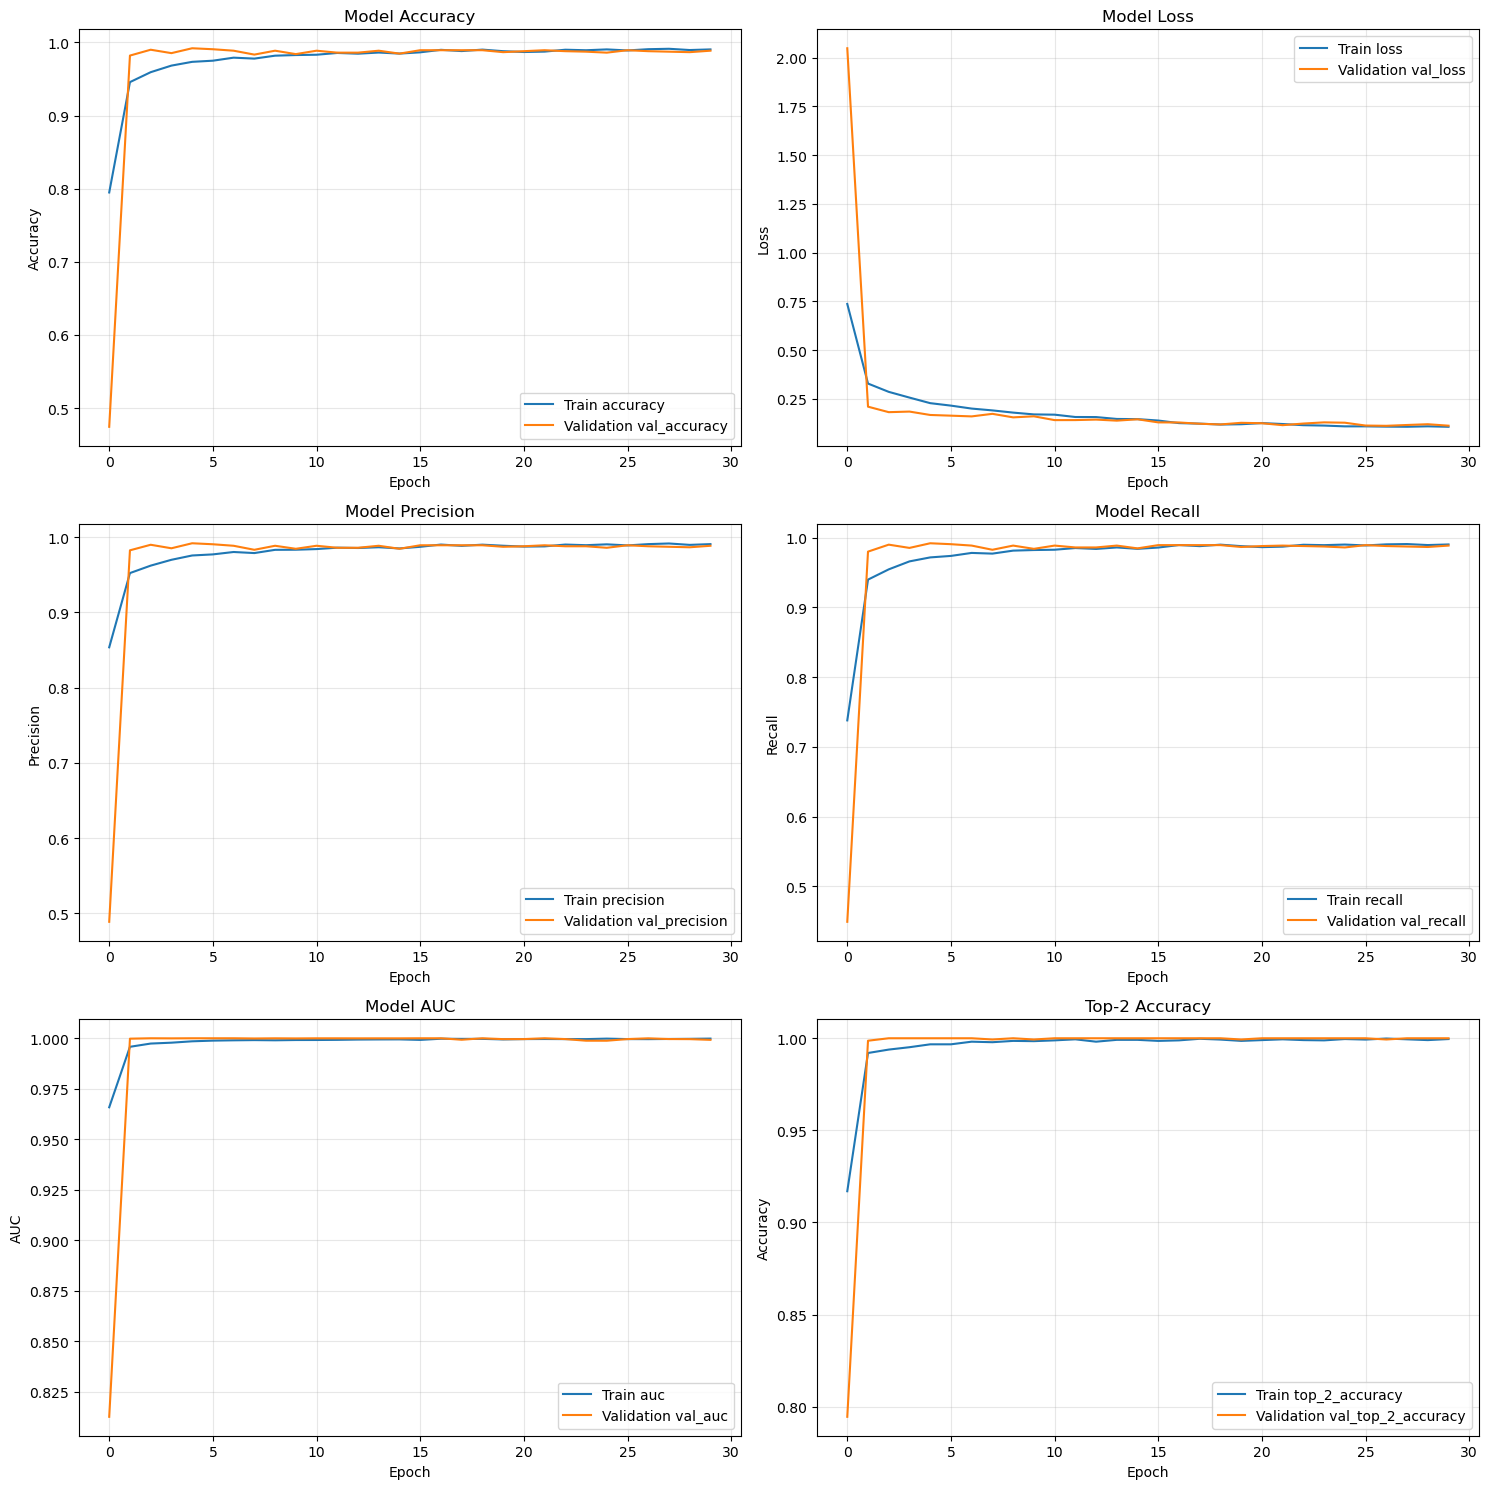

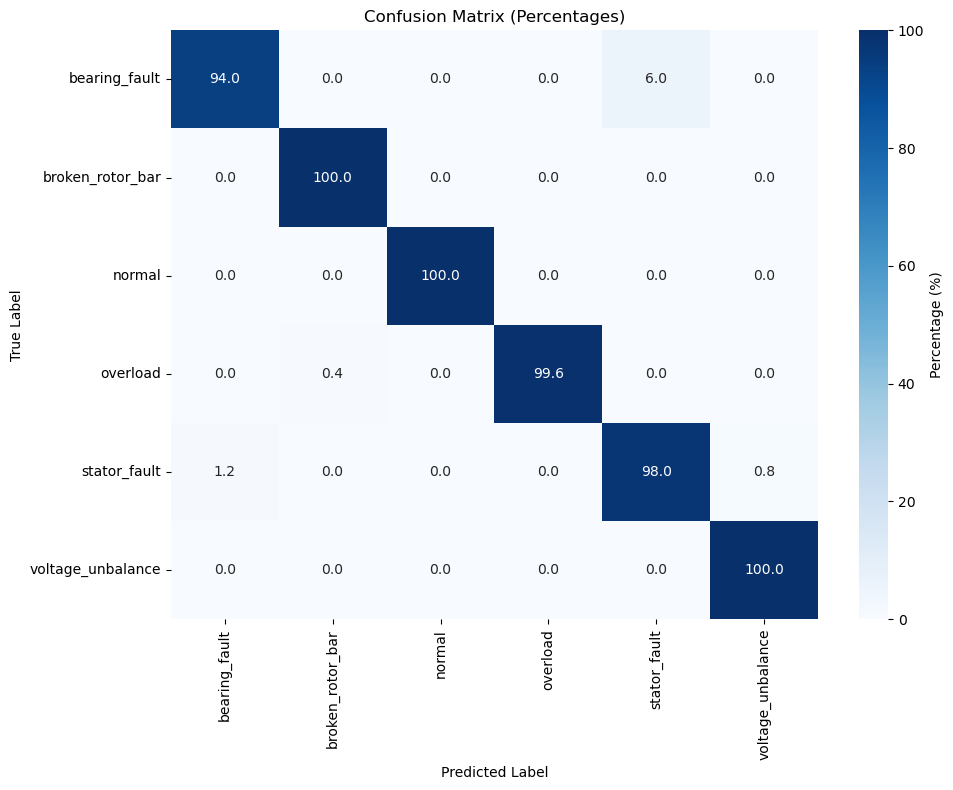

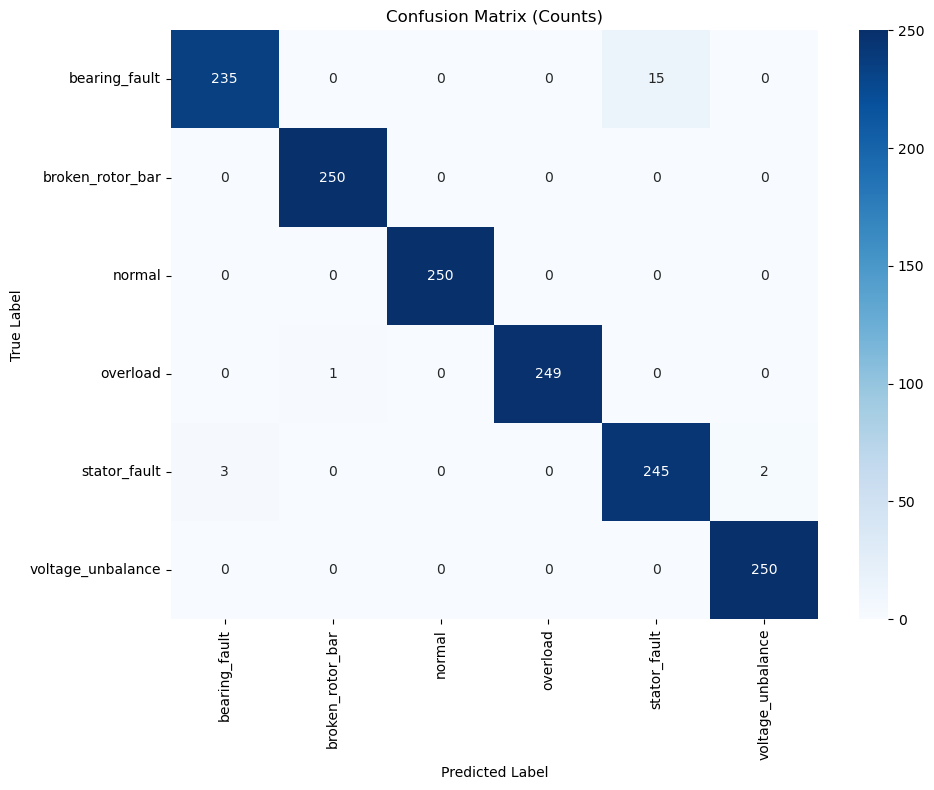


[STEP 9] TESTING PREDICTIONS

Testing on 3 random samples:
------------------------------------------------------------

Sample 1:
  True class:      stator_fault
  Predicted class: stator_fault (confidence: 0.998)
  Correct:         True
  Top 3:           [('stator_fault', 0.9982151985168457), ('bearing_fault', 0.0016887658275663853), ('broken_rotor_bar', 5.0754370022332296e-05)]

Sample 2:
  True class:      overload
  Predicted class: overload (confidence: 1.000)
  Correct:         True
  Top 3:           [('overload', 0.9999762773513794), ('broken_rotor_bar', 1.5714520486653782e-05), ('normal', 5.636392870655982e-06)]

Sample 3:
  True class:      overload
  Predicted class: overload (confidence: 1.000)
  Correct:         True
  Top 3:           [('overload', 0.9999793767929077), ('broken_rotor_bar', 1.3502899491868448e-05), ('normal', 6.244204541872023e-06)]

FINAL PROJECT REPORT

Project Summary:
  Architecture: Hybrid CNN-LSTM with Attention Mechanism
  Dataset: Fault Inductio

In [14]:
# 12. RUN THE PIPELINE
if __name__ == "__main__":
    try:
        print("Starting Predictive Maintenance Project...")
        model, history, report = main()
        print("\n" + "="*80)
        print("SUCCESS: All tasks completed successfully!")
        print("="*80)
        print("\nCheck the generated files in the current directory.")
        
        # Display final performance summary
        print("\nFinal Performance Summary:")
        print(f"  Test Accuracy:  {report['performance_metrics']['accuracy']:.4f}")
        print(f"  Test Precision: {report['performance_metrics']['precision']:.4f}")
        print(f"  Test Recall:    {report['performance_metrics']['recall']:.4f}")
        print(f"  Test F1-Score:  {report['performance_metrics']['f1_score']:.4f}")
        
    except Exception as e:
        print(f"\n" + "="*80)
        print("ERROR: Project execution failed!")
        print("="*80)
        print(f"\nError: {e}")
        print("\nTraceback:")
        import traceback
        traceback.print_exc()
        
        print("\nTroubleshooting tips:")
        print("1. Make sure all required packages are installed")
        print("2. Check if you have internet connection for dataset download")
        print("3. Try reducing dataset size or model complexity")
        print("4. Run each step separately to identify the exact issue")